# Code to clean, decode and combine 2019 and 2021 TBI Data. 

gde 10.25.2022

In [1]:
import pandas as pd
import numpy as np
import keyring
from timezonefinder import TimezoneFinder
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

In [3]:
# User set the main directory using keyring.  For example:
#    import keyring
#    keyring.set_password('msp', 'vmt_reduction_dir', 'path to the desired directory')
# This will be saved on your local machine

teams_dir = keyring.get_password('msp', 'vmt_reduction_dir')

data_dir_2019 = teams_dir + "/Data/TBI Wave 1 Dataset 20200630 - decoded/"
data_dir_2021 = teams_dir + "/Data/Wave 2 Data Deliverable/"

out_file = teams_dir + "/Data_Processed/tbi_merged.csv"

In [4]:
# these parameter files can be stored in github

# The equiv files lists which columns to keep, and how to rename them as needed
merging_table = pd.read_csv('params/variable_merging.csv')

# The 2019 data are already decoded.  This adds 2021
value_labels = pd.read_csv('params/wave2_value_labels.csv')

# these are mostly county and state lookups and added at the end
value_labels_wave1 = pd.read_csv('params/wave1_value_labels.csv')

# these convert num travelers back to numbers so we can calculate VMT
value_labels_num_travelers = pd.read_csv('params/num_travelers_value_labels.csv')

### Read the household data, keep only relevant columns, rename columns, and merge

In [5]:
# The equiv files lists which columns to keep, and how to rename them as needed

subset = merging_table[(merging_table['table']=='hh') & (merging_table['variable_wave1']!='NONE')]
hh2019_equiv = dict(zip(subset.variable_wave1, subset.merged_variable))

subset = merging_table[(merging_table['table']=='hh') & (merging_table['variable_wave2']!='NONE')]
hh2021_equiv = dict(zip(subset.variable_wave2, subset.merged_variable))


In [6]:
# read the 2019 data, keep only the relevant columns, and rename as needed

hh2019 = pd.read_csv(data_dir_2019 + 'hh.csv')
hh2019['wave'] = 1
hh2019 = hh2019[hh2019_equiv.keys()]
hh2019 = hh2019.rename(columns=hh2019_equiv)

In [7]:
# read the 2021 data and add value lables
hh2021 = pd.read_csv(data_dir_2021 + 'hh.csv')
hh2021['wave'] = 2
variables = value_labels[value_labels['table']=='hh']['variable'].unique()
for var in variables: 
    labels = value_labels[(value_labels['table']=='hh') & (value_labels['variable']==var)]
    lookup = dict(zip(labels['value'], labels['label']))
    hh2021[var] = hh2021[var].replace(lookup)

In [8]:
# keep only the relevant columns, and rename as needed

hh2021 = hh2021[hh2021_equiv.keys()]
hh2021 = hh2021.rename(columns=hh2021_equiv)

In [9]:
# merge the 2019 and 2021 data
hh = pd.concat([hh2019, hh2021], ignore_index=True)

### Read the person data, keep only relevant columns, rename columns, and merge

In [10]:
# The equiv files lists which columns to keep, and how to rename them as needed

subset = merging_table[(merging_table['table']=='person') & (merging_table['variable_wave1']!='NONE')]
per2019_equiv = dict(zip(subset.variable_wave1, subset.merged_variable))

subset = merging_table[(merging_table['table']=='person') & (merging_table['variable_wave2']!='NONE')]
per2021_equiv = dict(zip(subset.variable_wave2, subset.merged_variable))


In [11]:
# read the 2019 data, keep only the relevant columns, and rename as needed

per2019 = pd.read_csv(data_dir_2019 + 'per.csv')
per2019['wave'] = 1
per2019 = per2019[per2019_equiv.keys()]
per2019 = per2019.rename(columns=per2019_equiv)

In [12]:
# read the 2021 data and add value labels

per2021 = pd.read_csv(data_dir_2021 + 'person.csv')
per2021['wave'] = 2
variables = value_labels[value_labels['table']=='person']['variable'].unique()
for var in variables: 
    labels = value_labels[(value_labels['table']=='person') & (value_labels['variable']==var)]
    lookup = dict(zip(labels['value'], labels['label']))
    per2021[var] = per2021[var].replace(lookup)

C:\Users\fishl\AppData\Local\Temp\ipykernel_13320\191339829.py:3: DtypeWarning: Columns (169) have mixed types. Specify dtype option on import or set low_memory=False.
  per2021 = pd.read_csv(data_dir_2021 + 'person.csv')


In [13]:
# read the 2021 data, keep only the relevant columns, and rename as needed

per2021 = per2021[per2021_equiv.keys()]
per2021 = per2021.rename(columns=per2021_equiv)

In [14]:
# merge the 2019 and 2021 data
per = pd.concat([per2019, per2021], ignore_index=True)

In [15]:
# recode license (wave 1) into can_drive (wave 2)

license_to_can_drive = {
"Yes (license or learner's permit)" : "Yes, drives",
"No"  : "No, does not drive",
"Missing: Skip logic" : "No, does not drive",
"Missing: Non-response" : "Missing"
}


per['can_drive'] = per['can_drive'].replace(license_to_can_drive)

### Read the day data, keep only relevant columns, rename columns, and merge

In [16]:
# The equiv files lists which columns to keep, and how to rename them as needed

subset = merging_table[(merging_table['table']=='day') & (merging_table['variable_wave1']!='NONE')]
day2019_equiv = dict(zip(subset.variable_wave1, subset.merged_variable))

subset = merging_table[(merging_table['table']=='day') & (merging_table['variable_wave2']!='NONE')]
day2021_equiv = dict(zip(subset.variable_wave2, subset.merged_variable))


In [17]:
# read the 2019 data, keep only the relevant columns, and rename as needed

day2019 = pd.read_csv(data_dir_2019 + 'day.csv')
day2019['wave'] = 1
day2019 = day2019[day2019_equiv.keys()]
day2019 = day2019.rename(columns=day2019_equiv)

In [18]:
# read the 2021 data and add value labels

day2021 = pd.read_csv(data_dir_2021 + 'day.csv')
day2021['wave'] = 2
variables = value_labels[value_labels['table']=='day']['variable'].unique()
for var in variables: 
    labels = value_labels[(value_labels['table']=='day') & (value_labels['variable']==var)]
    lookup = dict(zip(labels['value'], labels['label']))
    day2021[var] = day2021[var].replace(lookup)

In [19]:
# read the 2021 data, keep only the relevant columns, and rename as needed

day2021 = day2021[day2021_equiv.keys()]
day2021 = day2021.rename(columns=day2021_equiv)

In [20]:
# merge the 2019 and 2021 data
day = pd.concat([day2019, day2021], ignore_index=True)

### Read the trip data, keep only relevant columns, rename columns, and merge

In [21]:
# The equiv files lists which columns to keep, and how to rename them as needed

subset = merging_table[(merging_table['table']=='trip') & (merging_table['variable_wave1']!='NONE')]
trip2019_equiv = dict(zip(subset.variable_wave1, subset.merged_variable))

subset = merging_table[(merging_table['table']=='trip') & (merging_table['variable_wave2']!='NONE')]
trip2021_equiv = dict(zip(subset.variable_wave2, subset.merged_variable))

In [22]:
# read the 2019 data, keep only the relevant columns, and rename as needed

trip2019 = pd.read_csv(data_dir_2019 + 'trip.csv')
trip2019['wave'] = 1
trip2019 = trip2019[trip2019_equiv.keys()]
trip2019 = trip2019.rename(columns=trip2019_equiv)

In [23]:
# read the 2021 data and add value labels

trip2021 = pd.read_csv(data_dir_2021 + 'trip.csv')
trip2021['wave'] = 2
variables = value_labels[value_labels['table']=='trip']['variable'].unique()
for var in variables: 
    labels = value_labels[(value_labels['table']=='trip') & (value_labels['variable']==var)]
    lookup = dict(zip(labels['value'], labels['label']))
    trip2021[var] = trip2021[var].replace(lookup)

In [24]:
# read the 2021 data, keep only the relevant columns, and rename as needed

trip2021 = trip2021[trip2021_equiv.keys()]
trip2021 = trip2021.rename(columns=trip2021_equiv)

In [25]:
# merge the 2019 and 2021 data
trip = pd.concat([trip2019, trip2021], ignore_index=True)

In [26]:
# clean up departure and arrival timestamps
trip['depart_time'] = pd.to_datetime(trip['depart_time'])
trip['arrive_time'] = pd.to_datetime(trip['arrive_time'])

trip['depart_time'] = trip['depart_time'].apply(lambda x: None if pd.isnull(x) else x.time())
trip['arrive_time'] = trip['arrive_time'].apply(lambda x: None if pd.isnull(x) else x.time())

### convert from unlinked trips to linked trips

In [27]:
# add logic to link out stops for gas -- these are not necessary if switching modes
trip = trip.sort_values(by=['wave', 'hh_id', 'person_id', 'day_num', 'trip_num'])

# see if it matches with the trip before
trip['wave_change'] = trip.wave - trip.wave.shift(1)
trip['person_change'] = trip.person_id - trip.person_id.shift(1)
trip['day_change'] = trip.day_num - trip.day_num.shift(1)
trip['same_day'] = np.where(((trip.wave_change==0) & (trip.person_change==0) & (trip.day_change==0)), 1, 0)

# get the origin and destination of the trip before
trip['o_purpose_before'] = np.where(trip.same_day==1, trip.o_purpose.shift(1), None)
trip['d_purpose_before'] = np.where(trip.same_day==1, trip.d_purpose.shift(1), None)

# identify trips where the origin purpose is getting gas, and the 
trip['o_purpose_gas'] = np.where(((trip.o_purpose=='Get gas') | (trip.o_purpose=='Got gas')), 1, 0)
trip['d_purpose_before_gas'] = np.where(((trip.d_purpose_before=='Get gas') | (trip.d_purpose_before=='Got gas')), 1, 0)

# simple tour where gas is the only stop
trip['gas_only_tour'] = np.where((trip.o_purpose_before=='Went home') & (trip.d_purpose=='Went home'), 1, 0)

# link trips that are on the same day, where the origin purpose is gas and where the destination of the last
# trip was gas, and it's not a simple tour where the only destination is gas
trip['gas_link'] = np.where((trip.same_day) 
                            & (trip.o_purpose_gas) 
                            & (trip.d_purpose_before_gas)
                            & (trip.gas_only_tour==0), 
                            1, 0)

# if it's a linked out gas trip, set the linked trip id to the previous value
trip.linked_trip_id = np.where(trip.gas_link==1, trip.linked_trip_id.shift(1), trip.linked_trip_id)

In [28]:
# assign a priority to each mode

mode_priority = {
'Long distance passenger mode': 1,
'School bus': 2,
'Ferry': 3,
'Rail': 4,
'Public bus': 5,
'Other bus': 6,
'Shuttle': 7,
'Transit': 8,
'Taxi': 9,
'Household vehicle': 10,
'Other vehicle': 11,
'Vehicle': 12,
'Carshare': 13,
'For-hire vehicle': 14,
'Smartphone ridehailing service': 15,
'Smartphone-app ride-hailing service': 16,
'Bicycle or e-bicycle': 17,
'Bike-share': 18,
'Scooter-share': 19,
'Micromobility': 20,
'Walk': 21,
'Missing: Non-response': 97,
'Missing': 98,
'Other': 99
}

trip['mode_priority'] = trip['mode_type'].apply(lambda x : mode_priority[x])

mode_priority_invert = {}
for key in mode_priority:
    mode_priority_invert[mode_priority[key]] = key

# code into aggregate groupings
main_mode_recode = {
'Long distance passenger mode': 'Long distance passenger mode',
'School bus': 'School bus',
'Ferry': 'Transit',
'Rail': 'Transit',
'Public bus': 'Transit',
'Other bus': 'Transit',
'Shuttle': 'Transit',
'Transit': 'Transit',
'Household vehicle': 'Car',
'Other vehicle': 'Car',
'Vehicle': 'Car',
'Taxi': 'Taxi/Ridehail/Carshare',
'Carshare': 'Taxi/Ridehail/Carshare',
'For-hire vehicle': 'Taxi/Ridehail/Carshare',
'Smartphone ridehailing service': 'Taxi/Ridehail/Carshare',
'Smartphone-app ride-hailing service': 'Taxi/Ridehail/Carshare',
'Bicycle or e-bicycle': 'Bike/Scooter',
'Bike-share': 'Bike/Scooter',
'Scooter-share': 'Bike/Scooter',
'Micromobility': 'Bike/Scooter',
'Walk': 'Walk',
'Missing: Non-response': 'Missing/Other',
'Missing': 'Missing/Other',
'Other': 'Missing/Other'
}


In [29]:
# determine how the columns get aggregated
agg_functions = {'trip_num' : 'count',  
                 'trip_id' : pd.Series.tolist, 
                 'travel_date' : 'first',  
                 'trip_weight' : 'first', 
                 'depart_time' : 'first', 
                 'arrive_time' : 'last', # want to get the last arrival time, which is the actual arrival time 
                 'duration' : 'sum', 
                 'distance' : 'sum', 
                 'speed_mph' : 'mean',
                 'o_lat' : 'first', 
                 'o_lon' : 'first', 
                 'o_bg_2010' : 'first', 
                 'o_county' : 'first', 
                 'o_state' : 'first', 
                 'd_lat' : 'last', 
                 'd_lon' : 'last', 
                 'd_bg_2010' : 'last', 
                 'd_county' : 'last', 
                 'd_state' : 'last', 
                 'trip_survey_complete' : 'first', 
                 'o_purpose' : 'first', 
                 'o_purpose_category' : 'first', 
                 'd_purpose' : 'last', 
                 'd_purpose_category' : 'last', 
                 'num_travelers' : 'first', 
                 'num_hh_travelers' : 'first', 
                 'num_non_hh_travelers' : 'first', 
                 'vehicle_id' : 'first', 
                 'mode_priority' : 'min', 
                 'gas_link' : 'max'}

In [30]:
# sort then merge
trip = trip.sort_values(by=['wave', 'hh_id', 'person_id', 'day_num', 'trip_num'])
linked_trip = trip.groupby(['wave', 'hh_id', 'person_id', 'day_num', 'linked_trip_id']).agg(agg_functions)
linked_trip = linked_trip.reset_index()

In [31]:
# some clean-up
linked_trip = linked_trip.rename(columns={'trip_num' : 'num_unlinked_trips'})
linked_trip.speed_mph = linked_trip.distance / (linked_trip.duration/60.)

In [32]:
# recode modes
linked_trip['detailed_mode'] = linked_trip['mode_priority'].apply(lambda x : mode_priority_invert[x])
linked_trip['mode'] = linked_trip['detailed_mode'].apply(lambda x : main_mode_recode[x])

### Merge HH, person, day and trip

In [107]:
# merge
df = linked_trip.merge(day, how='left', on=['wave', 'hh_id', 'person_id', 'day_num'], suffixes=(None, '_y'))
df = df.merge(per, how='left', on=['wave', 'hh_id', 'person_id'], suffixes=(None, '_y'))
df = df.merge(hh, how='left', on=['wave', 'hh_id'], suffixes=(None, '_y'))

In [108]:
# drop duplicate columns
duplicates = []
for col in df.columns: 
    if '_y' in col: 
        duplicates.append(col)
        
df = df.drop(columns=duplicates)

In [109]:
# apply labels for wave 1, primarily to county and state

variables = value_labels_wave1['variable'].unique()
for var in variables: 
    if var in df.columns: 
        labels = value_labels_wave1[(value_labels_wave1['variable']==var)]
        lookup = dict(zip(labels['value'], labels['label']))
        df[var] = df[var].replace(lookup)
        
# value labels to convert num_travelers to numbers needs to be done separately
# to avoid a string vs int inference problem
variables = value_labels_num_travelers['variable'].unique()
for var in variables: 
    if var in df.columns: 
        labels = value_labels_num_travelers[(value_labels_num_travelers['variable']==var)]
        lookup = dict(zip(labels['value'], labels['label']))
        df[var] = df[var].replace(lookup)        

In [110]:
# calculate vehicle trips and VMT

# only count car trips
df['vehicle_trips'] = df['mode'].apply(lambda x : 1 if (x=='Car') | (x=='Taxi/Ridehail/Carshare') else 0)

# assume 1 person if the num_travelers is missing
df['num_travelers_float'] = df['num_travelers'].apply(lambda x : 1 if x=='Missing' else x)
df['num_travelers_float'] = df['num_travelers_float'].apply(lambda x : float(x))

# divide vehicle trips by occupancy
df['vehicle_trips'] = df['vehicle_trips'] / df['num_travelers_float']

# vmt is vehicle trips times distance
df['vmt'] = df['vehicle_trips'] * df['distance']

In [111]:
# organize columns
col_order = [
    'wave',
    'hh_id',
    'person_id',
    'person_num',
    'day_num',
    'linked_trip_id',
    'trip_id', 
    'travel_date',
    'travel_dow',
    'depart_time',
    'arrive_time',
    'duration',
    'distance',
    'speed_mph',
    'vehicle_trips', 
    'vmt', 
    'o_lat',
    'o_lon',
    'o_bg_2010',
    'o_county',
    'o_state',
    'd_lat',
    'd_lon',
    'd_bg_2010',
    'd_county',
    'd_state',
    'mode',
    'detailed_mode',
    'o_purpose',
    'o_purpose_category',
    'd_purpose',
    'd_purpose_category',
    'num_travelers',
    'num_hh_travelers',
    'num_non_hh_travelers',
    'num_unlinked_trips',
    'gas_link', 
    'home_lat',
    'home_lon',
    'home_bg_2010',
    'home_county',
    'home_state',
    'income_broad',
    'income_detailed',
    'rent_own',
    'rent_cost',
    'residence_type',
    'num_adults',
    'num_kids',
    'num_students',
    'num_workers',
    'num_vehicles',
    'relationship',
    'age',
    'gender',
    'disability',
    'education',
    'student_status',
    'school_attend',
    'employment_status',
    'num_jobs',
    'job_type',
    'can_drive',
    'transportation_barriers_1',
    'transportation_barriers_2',
    'transportation_barriers_3',
    'transportation_barriers_4',
    'transportation_barriers_5',
    'transportation_barriers_997',
    'transportation_barriers_999',
    'day_complete',
    'trip_survey_complete',
    'hh_weight',
    'person_weight',
    'day_weight',
    'trip_weight'
    ]

df = df[col_order]

### Exclusions

In [112]:
print('Excluding missing lat, lon or timestamp.')
print('    Trips before exclusions: ' + str(len(df)) + ", VMT before exclusion: " + str(round(df.vmt.sum(),0)))

df = df[df.o_lat.notnull()]
df = df[df.o_lon.notnull()]
df = df[df.d_lat.notnull()]
df = df[df.d_lon.notnull()]

df = df[df.depart_time.notnull()]
df = df[df.arrive_time.notnull()]

print('    Trips after exclusions: ' + str(len(df)) + ", VMT after exclusion: " + str(round(df.vmt.sum(),0)))


Excluding missing lat, lon or timestamp.
    Trips before exclusions: 511082, VMT before exclusion: 2587103.0
    Trips after exclusions: 511080, VMT after exclusion: 2587103.0


In [113]:
# limit to trips within these 19 counties
study_area_counties = ["Anoka", 
                       "Carver", 
                       "Chisago", 
                       "Dakota", 
                       "Goodhue", 
                       "Hennepin", 
                       "Isanti", 
                       "Le Sueur", 
                       "McLeod", 
                       "Pierce", 
                       "Polk", 
                       "Ramsey", 
                       "Rice", 
                       "Scott", 
                       "Sherburne", 
                       "Sibley", 
                       "St Croix", 
                       "Washington", 
                       "Wright"]


In [114]:
print('Excluding where home location outside study area.')
print('    Trips before exclusions: ' + str(len(df)) + ", VMT before exclusion: " + str(round(df.vmt.sum(),0)))

df = df[df.home_county.apply(lambda x : x in study_area_counties)]

print('    Trips after exclusions: ' + str(len(df)) + ", VMT before exclusion: " + str(round(df.vmt.sum(),0)))

Excluding where home location outside study area.
    Trips before exclusions: 511080, VMT before exclusion: 2587103.0
    Trips after exclusions: 511080, VMT before exclusion: 2587103.0


In [115]:
print('Excluding where home origin or destination is outside study area.')
print('    Trips before exclusions: ' + str(len(df)) + ", VMT before exclusion: " + str(round(df.vmt.sum(),0)))

df = df[df.o_county.apply(lambda x : x in study_area_counties)]
df = df[df.d_county.apply(lambda x : x in study_area_counties)]

print('    Trips after exclusions: ' + str(len(df)) + ", VMT before exclusion: " + str(round(df.vmt.sum(),0)))

Excluding where home origin or destination is outside study area.
    Trips before exclusions: 511080, VMT before exclusion: 2587103.0
    Trips after exclusions: 473685, VMT before exclusion: 2031717.0


In [116]:
print('Excluding long-distance passenger modes.')
print('    Trips before exclusions: ' + str(len(df)) + ", VMT before exclusion: " + str(round(df.vmt.sum(),0)))

df = df[df['mode'] != 'Long distance passenger mode']

print('    Trips after exclusions: ' + str(len(df)) + ", VMT before exclusion: " + str(round(df.vmt.sum(),0)))

Excluding long-distance passenger modes.
    Trips before exclusions: 473685, VMT before exclusion: 2031717.0
    Trips after exclusions: 473519, VMT before exclusion: 2031717.0


In [117]:
print('Excluding missing modes modes.')
print('    Trips before exclusions: ' + str(len(df)) + ", VMT before exclusion: " + str(round(df.vmt.sum(),0)))

df = df[df['mode'] != 'Missing/Other']

print('    Trips after exclusions: ' + str(len(df)) + ", VMT before exclusion: " + str(round(df.vmt.sum(),0)))

Excluding missing modes modes.
    Trips before exclusions: 473519, VMT before exclusion: 2031717.0
    Trips after exclusions: 458362, VMT before exclusion: 2031717.0


In [118]:
print('Excluding trips too short.')
print('    Trips before exclusions: ' + str(len(df)) + ", VMT before exclusion: " + str(round(df.vmt.sum(),0)))

df = df[df['distance'] > 0.01]

print('    Trips after exclusions: ' + str(len(df)) + ", VMT before exclusion: " + str(round(df.vmt.sum(),0)))

Excluding trips too short.
    Trips before exclusions: 458362, VMT before exclusion: 2031717.0
    Trips after exclusions: 457987, VMT before exclusion: 2031717.0


In [119]:
print('Excluding trips too long')
print('    Trips before exclusions: ' + str(len(df)) + ", VMT before exclusion: " + str(round(df.vmt.sum(),0)))

df = df[df['distance'] <= 100]

print('    Trips after exclusions: ' + str(len(df)) + ", VMT before exclusion: " + str(round(df.vmt.sum(),0)))

Excluding trips too long
    Trips before exclusions: 457987, VMT before exclusion: 2031717.0
    Trips after exclusions: 457725, VMT before exclusion: 1963359.0


In [120]:
print('Excluding trips by ferry')
print('    Trips before exclusions: ' + str(len(df)) + ", VMT before exclusion: " + str(round(df.vmt.sum(),0)))

df = df[df['detailed_mode'] != 'Ferry']

print('    Trips after exclusions: ' + str(len(df)) + ", VMT before exclusion: " + str(round(df.vmt.sum(),0)))

Excluding trips by ferry
    Trips before exclusions: 457725, VMT before exclusion: 1963359.0
    Trips after exclusions: 457713, VMT before exclusion: 1963359.0


In [121]:
# handling daylight savings & time zone
tf = TimezoneFinder()

In [122]:
# getting origin/destination time zones of everything
df["o_timezone"] = linked_trip.apply(lambda x: tf.timezone_at(lng=x["o_lon"], lat=x["o_lat"]), axis=1)
df["d_timezone"] = linked_trip.apply(lambda x: tf.timezone_at(lng=x["d_lon"], lat=x["d_lat"]), axis=1)

In [123]:
# no time zone differences in the data
display(df["o_timezone"].value_counts())
display(df["d_timezone"].value_counts())

America/Chicago    457713
Name: o_timezone, dtype: int64

America/Chicago    457713
Name: d_timezone, dtype: int64

In [124]:
# get workable datetime data
df["depart_datetime"] = pd.to_datetime(df["travel_date"].astype(str) + ' ' + df["depart_time"].astype(str))
df["arrive_datetime"] = pd.to_datetime(df["travel_date"].astype(str) + ' ' + df["arrive_time"].astype(str))

In [125]:
# end of daylight savings is not an issue for abnormal durations 
df[(df["depart_datetime"].dt.month == 11) & (df["depart_datetime"].dt.day <= 10) & # daylight savings end is always in november and before the 10th
    # get all times where arrival time is somehow before the departure
    (df["arrive_datetime"].dt.hour <= df["depart_datetime"].dt.hour) & (df["arrive_datetime"].dt.minute < df["depart_datetime"].dt.minute)] \
    .query("duration > 1000") # if the dst wraparound were an issue, the duration would be about 1 day = 1440 minutes

,wave,hh_id,person_id,person_num,day_num,linked_trip_id,trip_id,travel_date,travel_dow,depart_time,arrive_time,duration,distance,speed_mph,vehicle_trips,vmt,o_lat,o_lon,o_bg_2010,o_county,o_state,d_lat,d_lon,d_bg_2010,d_county,d_state,mode,detailed_mode,o_purpose,o_purpose_category,d_purpose,d_purpose_category,num_travelers,num_hh_travelers,num_non_hh_travelers,num_unlinked_trips,gas_link,home_lat,home_lon,home_bg_2010,home_county,home_state,income_broad,income_detailed,rent_own,rent_cost,residence_type,num_adults,num_kids,num_students,num_workers,num_vehicles,relationship,age,gender,disability,education,student_status,school_attend,employment_status,num_jobs,job_type,can_drive,transportation_barriers_1,transportation_barriers_2,transportation_barriers_3,transportation_barriers_4,transportation_barriers_5,transportation_barriers_997,transportation_barriers_999,day_complete,trip_survey_complete,hh_weight,person_weight,day_weight,trip_weight,o_timezone,d_timezone,depart_datetime,arrive_datetime
62818,1,18684084,1868408402,2,5,16.0,[1868408402016],2018-11-02,Friday,15:26:31,09:01:48,1055.3,28.307270,1.609434,1.0,28.307270,45.02847,-93.04126,2.712304e+11,Ramsey,Minnesota,44.98498,-92.63042,5.510912e+11,St Croix,Wisconsin,Car,Household vehicle,Grocery shopping,Shop,Grocery shopping,Shop,1,1,0,1,0,44.98181,-92.66087,551091202022,St Croix,Wisconsin,"$100,000 or more","$200,000-$249,999",Own (includes paying a mortgage),Missing: Skip logic,Single-family house (detached house),2,1,1,3,3,Spouse or partner,45-54,Male,No,Bachelor's degree,No,Missing: Skip logic,Full-time,1,"Only one work location (outside of home, may a...","Yes, drives",NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,Yes,956.841350,956.841350,0.0,0.0,America/Chicago,America/Chicago,2018-11-02 15:26:31,2018-11-02 09:01:48
444009,2,21190560,2119056002,2,2,129471.0,[2119056002009],2021-11-06,Saturday,20:27:01,15:04:39,1118.0,5.301718,0.284529,0.5,2.650859,44.84394,-93.12386,2.703706e+11,Dakota,Minnesota,44.81837,-93.10649,2.703706e+11,Dakota,Minnesota,Car,Vehicle,"Social activity (e.g., visit friends/relatives)",Social/Recreation,Went home,Home,2,2,0,1,0,44.81871,-93.10665,270370607303,Dakota,Minnesota,"$200,000 or more","$200,000-$249,999",Own/buying (paying a mortgage),"$2,000 - $2,499",Single-family house (detached house),2,2,2,2,2,Husband/wife/spouse,25 to 34,Female,No,Graduate/post-graduate degree,Not a student,Missing,Employed full-time (paid),1,Go to one work location ONLY (outside of home),"Yes, drives",Not selected,Not selected,Not selected,Not selected,This has not happened in the past 7 days,Not selected,Not selected,No,Yes,362.545477,362.545477,0.0,0.0,America/Chicago,America/Chicago,2021-11-06 20:27:01,2021-11-06 15:04:39


In [126]:
# start of daylight savings is not an issue for abnormal durations 
df[(df["depart_datetime"].dt.month == 3) & (df["depart_datetime"].dt.day <= 14) & (df["depart_datetime"].dt.day >= 8) & # daylight savings start is always in march between 8-14
   (df["arrive_datetime"].dt.hour <= df["depart_datetime"].dt.hour) & (df["arrive_datetime"].dt.minute < df["depart_datetime"].dt.minute)]

,wave,hh_id,person_id,person_num,day_num,linked_trip_id,trip_id,travel_date,travel_dow,depart_time,arrive_time,duration,distance,speed_mph,vehicle_trips,vmt,o_lat,o_lon,o_bg_2010,o_county,o_state,d_lat,d_lon,d_bg_2010,d_county,d_state,mode,detailed_mode,o_purpose,o_purpose_category,d_purpose,d_purpose_category,num_travelers,num_hh_travelers,num_non_hh_travelers,num_unlinked_trips,gas_link,home_lat,home_lon,home_bg_2010,home_county,home_state,income_broad,income_detailed,rent_own,rent_cost,residence_type,num_adults,num_kids,num_students,num_workers,num_vehicles,relationship,age,gender,disability,education,student_status,school_attend,employment_status,num_jobs,job_type,can_drive,transportation_barriers_1,transportation_barriers_2,transportation_barriers_3,transportation_barriers_4,transportation_barriers_5,transportation_barriers_997,transportation_barriers_999,day_complete,trip_survey_complete,hh_weight,person_weight,day_weight,trip_weight,o_timezone,d_timezone,depart_datetime,arrive_datetime
167238,1,19351031,1935103102,2,4,11.0,[1935103102011],2019-03-14,Thursday,23:42:00,00:03:47,21.8,11.18869,30.794560,1.0,11.188690,45.02118,-93.47952,2.705303e+11,Hennepin,Minnesota,44.90790,-93.40961,2.705302e+11,Hennepin,Minnesota,Car,Household vehicle,Grocery shopping,Shop,Went home,Home,1,1,0,1,0,44.90779,-93.41095,270530234004,Hennepin,Minnesota,"$50,000-$74,999","$50,000-$74,999",Own (includes paying a mortgage),Missing: Skip logic,Building with 5 or more apartments or condos,2,0,0,2,2,Spouse or partner,25-34,Female,No,Bachelor's degree,No,Missing: Skip logic,Full-time,1,"Only one work location (outside of home, may a...","Yes, drives",NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,Yes,969.87502,969.87502,242.46875,242.46875,America/Chicago,America/Chicago,2019-03-14 23:42:00,2019-03-14 00:03:47
177391,1,19389611,1938961102,2,5,23.0,[1938961102023],2019-03-08,Friday,19:56:35,07:23:57,687.4,5.52651,0.482384,1.0,5.526510,45.09353,-93.44164,2.705303e+11,Hennepin,Minnesota,45.09904,-93.44100,2.705303e+11,Hennepin,Minnesota,Car,Household vehicle,Dine out/get coffee or take-out,Meal,Dine out/get coffee or take-out,Meal,1,1,0,1,0,45.10123,-93.49428,270530267152,Hennepin,Minnesota,"$100,000 or more","$250,000 or more",Own (includes paying a mortgage),Missing: Skip logic,Single-family house (detached house),2,0,0,2,2,Spouse or partner,55-64,Male,No,Bachelor's degree,No,Missing: Skip logic,Full-time,1,"Only one work location (outside of home, may a...","Yes, drives",NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,Yes,199.11665,199.11665,0.00000,0.00000,America/Chicago,America/Chicago,2019-03-08 19:56:35,2019-03-08 07:23:57
218588,1,19539451,1953945101,1,2,11.0,[1953945101011],2019-03-12,Tuesday,20:27:40,00:04:27,216.8,9.81499,2.716326,0.5,4.907495,44.95732,-93.27929,2.705311e+11,Hennepin,Minnesota,44.85203,-93.41359,2.705303e+11,Hennepin,Minnesota,Car,Household vehicle,"Leisure/entertain/cultural (e.g., cinema, museum)",Social/Recreation,Went home,Home,2,2,0,1,0,44.85216,-93.41352,270530260202,Hennepin,Minnesota,"$50,000-$74,999","$50,000-$74,999",Own (includes paying a mortgage),Missing: Skip logic,"Building with 2-4 units (duplexes, triplexes, ...",2,0,0,0,2,Self,65-74,Female,No,Graduate/post-graduate degree,No,Missing: Skip logic,Not employed,Missing: Skip logic,Missing: Skip logic,"Yes, drives",NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,Yes,48.87369,48.87369,12.21842,12.21842,America/Chicago,America/Chicago,2019-03-12 20:27:40,2019-03-12 00:04:27
284950,1,19781245,1978124502,2,4,15.0,[1978124502015],2019-03-14,Thursday,13:44:55,04:34:09,889.2,5.00045,0.337412,1.0,5.000450,44.94778,-93.10065,2.712303e+11,Ramsey,Minnesota,44.93433,-93.19254,2.712304e+11,Ramsey,Minnesota,Car,Household vehicle,Primary workplace,Work,"Exercise (e.g., gym, jog, bike, walk dog)",Social/Recreation,1,1,0,1,0,44.92822,-93.19560,271230430001,Ramsey,Minnesota,"$100,000 or more","$200,000-$249,999",Own (includes paying a mortgage),Missing: Skip logic,Single-family house (detached house),2,0,0,2,2,Spouse or par

In [127]:
def recalc_duration(row):
    """This function recalcaultes durations for trips with seemingly non-sensically high durations w.r.t their arrival/departure times. 

    Args:
        row (pd.Series): a trip

    Returns:
        duration: an adjusted duration (or the original if no adjustment needed)
    """
    new_duration = (row["arrive_datetime"] - row["depart_datetime"]).seconds / 60
    cur_duration = row["duration"]
    if (new_duration == 0):
        return cur_duration
    if cur_duration / new_duration > 2: # only adjust for extreme errors where the cur_duration is wildly high (low is okay due to self-reporting bias being more significant with smaller durations)
        return new_duration
    return cur_duration

In [128]:
# manually recalcaulte duration based on arrival and departure time reported only if the adjusted duration is half or less the original
# don't do this for everything because arrival/departure time is self-reported in some cases
df["duration_adj"] = df.apply(recalc_duration, axis=1)

In [129]:
# outliers are grealty reduced
display(df["duration"].describe())
display(df["duration_adj"].describe())

count    457713.000000
mean         27.290738
std         100.162763
min           0.000000
25%           8.000000
50%          14.000000
75%          23.000000
max        6194.000000
Name: duration, dtype: float64

count    457713.000000
mean         20.565949
std          41.574284
min           0.000000
25%           8.000000
50%          13.800000
75%          22.900000
max        1439.000000
Name: duration_adj, dtype: float64

In [130]:
df["speed_mph_adj"] = df.distance / (df.duration_adj/60. + 0.01) # add 0.01 to the denominator to deal with 0 durations

In [131]:
MAX_ACCEPTABLE_SQUARE_DIST = 2

def lookup_duration(row):
    """This function manually searches for more reasonable durations based off other trips an individual has gone on (i.e., copy the duration of the trip whose distance most closely matches a given linked trips's distance)

    Args:
        row (row): the row of the linked trip whose duration should be recalculated

    Returns:
        duration: the original duration if the lookup failed, and the closest duration (w.r.t distance) if a reference point was found
    """
    # extract person id and the current linked trip id
    person_id = row["person_id"]
    trip_id = row["linked_trip_id"]

    # get all trips the individual has gone on, excluding the current trip being queried
    subset = df[df["person_id"] == person_id]
    # get the distance of the current trip
    target = subset.loc[subset["linked_trip_id"] == trip_id, "distance"].values[0]
    subset = subset[subset["linked_trip_id"] != trip_id]
    
    
    # find the trip closest in distance to current trip's distance
    curr_min = float("inf")
    res = -1
    for _, x in subset.iterrows():
        if (x["distance"] - target) ** 2 < curr_min:
            curr_min = (x["distance"] - target) ** 2
            res = x["linked_trip_id"]
            
    # if nothing found or the reference trip isn't close enough, return hte original duration
    if curr_min >= MAX_ACCEPTABLE_SQUARE_DIST or len(df[(df["person_id"] == person_id) & (df["linked_trip_id"] == res)]["duration_adj"].values) == 0:
        return row["duration_adj"]

    return df[(df["person_id"] == person_id) & (df["linked_trip_id"] == res)]["duration_adj"].values[0]

In [132]:
MAX_ACCEPTABLE_LATLON_DIST = (1.0 / 60) ** 2 # one mile in degrees, roughly; reference trip should be at maximum 1 mile off
def get_squared_distance(x, y):
    return (float(x[0]) - float(y[0])) ** 2 + (float(x[1]) - float(y[1])) ** 2

def lookup_duration_from_loc(row):
    """This function manually searches for more reasonable durations based off other trips an individual has gone on (i.e., copy the duration of the trip whose origin/destination latlons most closely matches a given linked trips's origin/destination latlons, in either order)
    
    This function should theoretically be more accurate than the lookup_duration function as it uses a more invariant metric--latlon. 

    Args:
        row (row): the row of the linked trip whose duration should be recalculated

    Returns:
        duration: the original duration if the lookup failed, and the closest duration (w.r.t latlons irrespective of origin/destination) if a reference point was found
    """
    # extract person id and the current linked trip id
    person_id = row["person_id"]
    trip_id = row["linked_trip_id"]

    # get all trips the individual has gone on, excluding the current trip being queried
    subset = df[df["person_id"] == person_id]
    # get the latlons of the origin and destination of the current trip
    orig_lat, orig_lon = subset.loc[subset["linked_trip_id"] == trip_id, ["o_lat", "o_lon"]].iloc[0].values
    dest_lat, dest_lon = subset.loc[subset["linked_trip_id"] == trip_id, ["d_lat", "d_lon"]].iloc[0].values
    subset = subset[subset["linked_trip_id"] != trip_id]
    
    # find the trip closest in distance to current trip's latlon (check both origin-destination and destination-origin ordering)
    curr_min = float("inf")
    res = -1
    for _, x in subset.iterrows():
        if get_squared_distance((orig_lat, orig_lon), (x["o_lat"], x["o_lon"])) + \
                get_squared_distance((dest_lat, dest_lon), (x["d_lat"], x["d_lon"])) < curr_min:
                    
            curr_min = get_squared_distance((orig_lat, orig_lon), (x["o_lat"], x["o_lon"])) + \
                get_squared_distance((dest_lat, dest_lon), (x["d_lat"], x["d_lon"]))
            res = x["linked_trip_id"]
            
        if get_squared_distance((dest_lat, dest_lon), (x["o_lat"], x["o_lon"])) + \
                get_squared_distance((orig_lat, orig_lon), (x["d_lat"], x["d_lon"])) < curr_min:
                    
            curr_min = get_squared_distance((dest_lat, dest_lon), (x["o_lat"], x["o_lon"])) + \
                get_squared_distance((orig_lat, orig_lon), (x["d_lat"], x["d_lon"]))
            res = x["linked_trip_id"]
    
    # if nothing found or the reference trip isn't close enough or if the reference trip doesn't use hte same mode, return hte original duration
    if curr_min >= MAX_ACCEPTABLE_LATLON_DIST or len(df[(df["person_id"] == person_id) & (df["linked_trip_id"] == res)]["duration_adj"].values) == 0 or \
        (row["mode"] != df[(df["person_id"] == person_id) & (df["linked_trip_id"] == res)]["mode"]).values[0]:
        return row["duration_adj"]

    return df[(df["person_id"] == person_id) & (df["linked_trip_id"] == res)]["duration_adj"].values[0]

In [133]:
mask = (df["duration_adj"] > 300) & (df["speed_mph_adj"] < 2) # want to fix things with high durations but only the ones with abnormally low speeds (there could be high duration, high speed longer distance trips)
print(mask.sum())
df.loc[mask, "duration_adj"] = df[mask].apply(lambda x: lookup_duration_from_loc(x), axis=1)

1116


In [134]:
df["duration_adj"].describe() # removes some more outliers

count    457713.000000
mean         19.569759
std          31.217470
min           0.000000
25%           8.000000
50%          13.800000
75%          22.800000
max        1420.600000
Name: duration_adj, dtype: float64

In [135]:
df["speed_mph_adj"] = df.distance / (df.duration_adj/60. + 0.01)

In [136]:
df["speed_mph_adj"].describe()

count    457713.000000
mean         18.868646
std          35.460548
min           0.003921
25%           6.995018
50%          15.353480
75%          26.213314
max        4805.399981
Name: speed_mph_adj, dtype: float64

<Axes: xlabel='speed_mph_adj', ylabel='Count'>

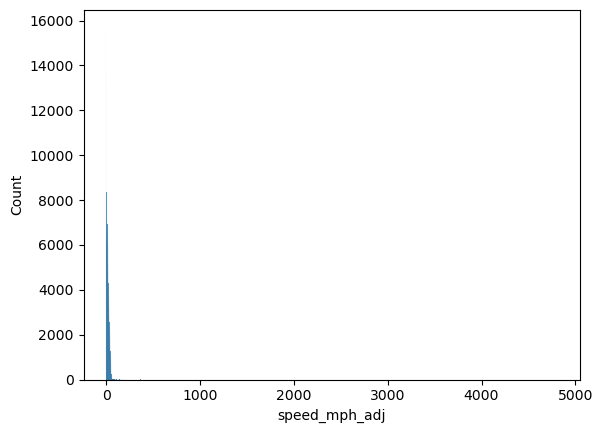

In [137]:
sns.histplot(df["speed_mph_adj"])

In [138]:
final_df = df.copy()

In [139]:
print('Excluding trips with unreasonable duration')
print('    Trips before exclusions: ' + str(len(final_df)) + ", VMT before exclusion: " + str(round(final_df.vmt.sum(),0)))

final_mask = final_df["duration_adj"] >= 0.1 # filter out trips that are 6 seconds or less
final_mask &= ((final_df["duration_adj"] <= 300) | (df["speed_mph_adj"] >= 3)) # filter out extremely long trips that aren't reasonably paced
final_df = final_df[final_mask]

print('    Trips after exclusions: ' + str(len(final_df)) + ", VMT before exclusion: " + str(round(final_df.vmt.sum(),0)))

Excluding trips with unreasonable duration
    Trips before exclusions: 457713, VMT before exclusion: 1963359.0
    Trips after exclusions: 454143, VMT before exclusion: 1956539.0


In [140]:
print('Excluding trips with unreasonable speed')
print('    Trips before exclusions: ' + str(len(final_df)) + ", VMT before exclusion: " + str(round(final_df.vmt.sum(),0)))

final_mask = final_df["speed_mph_adj"] <= 100 # filter out extremely fast trips
final_mask &= final_df["speed_mph_adj"] >= 0.1 # filter out extremely slow trips
final_df = final_df[final_mask]

print('    Trips after exclusions: ' + str(len(final_df)) + ", VMT before exclusion: " + str(round(final_df.vmt.sum(),0)))

Excluding trips with unreasonable speed
    Trips before exclusions: 454143, VMT before exclusion: 1956539.0
    Trips after exclusions: 453259, VMT before exclusion: 1947666.0


In [141]:
final_df["duration"] = final_df["duration_adj"]
final_df["speed_mph"] = final_df["distance"] / (final_df["duration"] + 0.01)

In [142]:
final_df = final_df[col_order]

In [145]:
# final_df.to_csv(teams_dir + "/Data_Processed/tbi_cleaned.csv")
final_df.to_csv("tbi_cleaned.csv")

In [144]:
# # write the file
# df.to_csv(out_file)